# Empirical Methods in Finance — Class 1 (Applied Notebook)

**Topic:** Exploring returns, expectations, and volatility stylized facts (weekly data, 1999–2021).

**How to use live in class**
- Run cells top-to-bottom.
- When you see a ✅ *Teaching prompt*, pause and ask students to interpret before revealing the next cell.
- Cells labeled 🧩 *Student challenge* contain small tasks you can give in real time.


## 0. Imports & global settings

In [1]:
# Core stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Stats / econometrics
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf

# Display options
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

# Reproducibility
np.random.seed(0)

# IMPORTANT for class: keep plots readable
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## 1. Load the dataset

We use the class dataset of **7 assets/indices** (weekly, end-of-week levels).  
Assets:
- World Equities
- Emerging Equities
- World Bonds
- US High Yield
- Oil
- Dollar
- Gold


In [2]:
import os

# ---- Data loading ----
# The CSV is in the same folder as this notebook.
CSV_PATH = "Data_HEC_1 (1).csv"

# The file is semicolon-separated and the first column is a date in dd.mm.yyyy format
raw = pd.read_csv(CSV_PATH, sep=";")
raw = raw.rename(columns={"Unnamed: 0": "Date"})

raw["Date"] = pd.to_datetime(raw["Date"], format="%d.%m.%Y")
raw = raw.sort_values("Date").set_index("Date")

raw.head()


,World Equities,Emerging Equities,World Bonds,US High Yield,Oil,Dollar,Gold
Date,,,,,,,
1999-12-31,1420.89,489.42,140.509,508.108,25.60,101.87,288.00
2000-01-07,1375.88,492.10,140.697,505.785,24.22,100.72,281.75
2000-01-14,1402.14,515.63,139.454,505.351,28.02,101.72,284.20
2000-01-21,1376.52,507.49,139.421,505.370,29.66,101.81,289.10
2000-01-28,1334.47,499.05,138.197,505.752,27.22,104.48,283.25


### Sanity checks

In [3]:
assets = raw.columns.tolist()
print("Assets:", assets)
print("Date range:", raw.index.min().date(), "→", raw.index.max().date())
print("Observations:", raw.shape[0])

# Confirm sampling frequency (weekly)
freq_days = raw.index.to_series().diff().dt.days.dropna()
print("Unique step (days):", sorted(freq_days.unique())[:5])


Assets: ['World Equities', 'Emerging Equities', 'World Bonds', 'US High Yield', 'Oil', 'Dollar', 'Gold']
Date range: 1999-12-31 → 2021-02-19
Observations: 1104
Unique step (days): [np.float64(7.0)]


✅ Teaching prompt: *Why do we often work with returns instead of prices?*

## 2. From prices to returns (simple vs log)

Definitions (one-period):
- **Simple return:**  $R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$
- **Log return:** $r_t = \log(P_t) - \log(P_{t-1})$

In weekly data, both are close for small moves, but **log-returns aggregate nicely over time**.


In [4]:
prices = raw.copy()

log_prices = np.log(prices)

simple_ret = prices.pct_change()
log_ret = log_prices.diff()

simple_ret.head()



,World Equities,Emerging Equities,World Bonds,US High Yield,Oil,Dollar,Gold
Date,,,,,,,
1999-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,-0.031677,0.005476,0.001338,-0.004572,-0.053906,-0.011289,-0.021701
2000-01-14,0.019086,0.047815,-0.008835,-0.000858,0.156895,0.009929,0.008696
2000-01-21,-0.018272,-0.015787,-0.000237,0.000038,0.058530,0.000885,0.017241
2000-01-28,-0.030548,-0.016631,-0.008779,0.000756,-0.082266,0.026225,-0.020235


### Compare simple vs log returns (for one asset)

In [5]:
asset = "World Equities"

tmp = pd.DataFrame({
    "Simple": simple_ret[asset],
    "Log": log_ret[asset],
    "Diff (Simple-Log)": simple_ret[asset] - log_ret[asset],
}).dropna()

tmp.describe().T


,count,mean,std,min,25%,50%,75%,max
Simple,1103.0,0.000918,0.024348,-2.005322e-01,-0.010607,0.002485,0.013221,0.123408
Log,1103.0,0.000617,0.024648,-2.238090e-01,-0.010664,0.002481,0.013134,0.116367
Diff (Simple-Log),1103.0,0.000301,0.000992,2.006116e-09,0.000015,0.000074,0.000257,0.023277


✅ Teaching prompt: *When would you prefer simple returns? When would you prefer log returns?*

## 3. Visual exploration: prices, log prices, returns

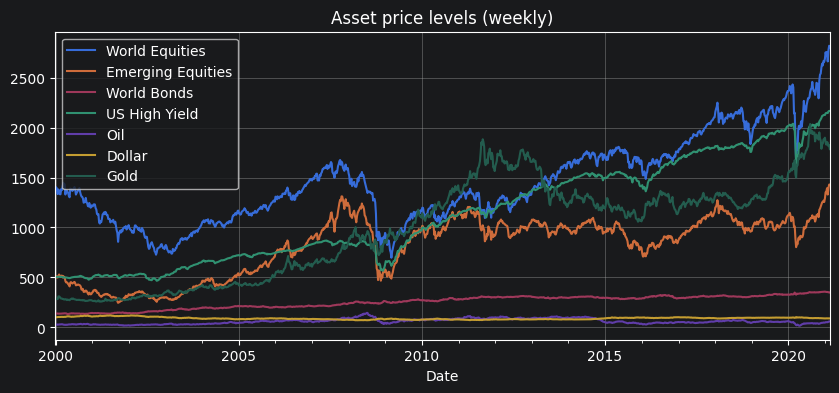

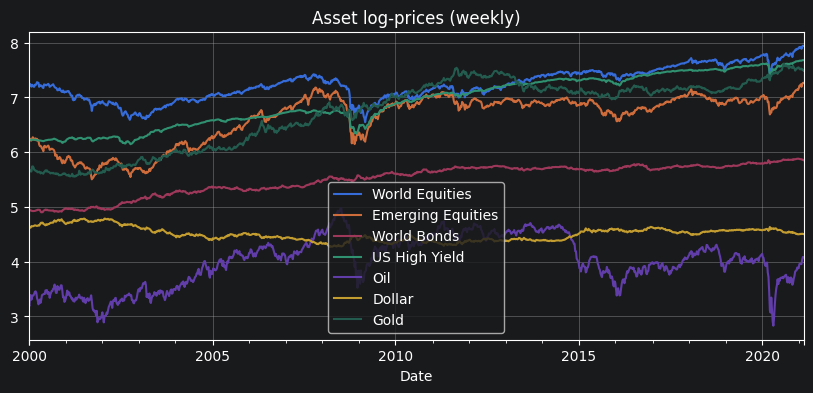

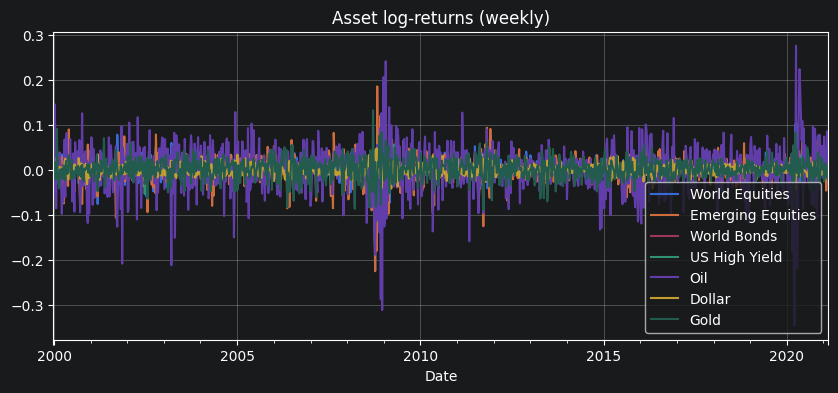

In [6]:
# Price levels
prices.plot(title="Asset price levels (weekly)")
plt.show()

# Log prices (more comparable trends)
log_prices.plot(title="Asset log-prices (weekly)")
plt.show()

# Log returns
log_ret.plot(title="Asset log-returns (weekly)")
plt.show()


## 4. Annualization (weekly → annual)

With weekly data (≈ 52 weeks / year):
- **Annualized volatility:**  $\sigma_{ann} \approx \sigma_{w} \sqrt{52}$
- For returns, two common conventions:
  - From *simple* weekly mean: $(1+\bar R_w)^{52} - 1$
  - From *log* weekly mean: $\exp(52\,\bar r_w) - 1$

Below we implement both.


In [7]:
WEEKS_PER_YEAR = 52

def annualize_from_weekly_simple(mean_weekly_simple: float) -> float:
    return (1.0 + mean_weekly_simple) ** WEEKS_PER_YEAR - 1.0

def annualize_from_weekly_log(mean_weekly_log: float) -> float:
    return np.exp(WEEKS_PER_YEAR * mean_weekly_log) - 1.0

def annualize_vol_from_weekly(std_weekly: float) -> float:
    return std_weekly * np.sqrt(WEEKS_PER_YEAR)

# Quick example
m_s = simple_ret["World Equities"].dropna().mean()
m_l = log_ret["World Equities"].dropna().mean()
s_l = log_ret["World Equities"].dropna().std()

print("World Equities:")
print("  Annual return (simple mean convention):", annualize_from_weekly_simple(m_s))
print("  Annual return (log mean convention):   ", annualize_from_weekly_log(m_l))
print("  Annual vol (from log returns):         ", annualize_vol_from_weekly(s_l))


World Equities:
  Annual return (simple mean convention): 0.04887898660399825
  Annual return (log mean convention):    0.032608769246514235
  Annual vol (from log returns):          0.17773881813855646


## 5. Descriptive statistics (moments)

We compute:
- Mean
- Volatility (std)
- Skewness
- Kurtosis (excess)

✅ Teaching prompt: *What does negative skew mean for an investor?*  
✅ Teaching prompt: *Why does excess kurtosis matter for risk management?*


In [8]:
def summary_stats(r: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=r.columns)
    out["mean_weekly"] = r.mean()
    out["vol_weekly"] = r.std()
    out["skew"] = r.apply(stats.skew, nan_policy="omit")
    out["excess_kurt"] = r.apply(stats.kurtosis, nan_policy="omit")  # Fisher => excess kurtosis

    # Annualize (log-return convention)
    out["mean_annual"] = out["mean_weekly"].apply(annualize_from_weekly_log)
    out["vol_annual"] = out["vol_weekly"].apply(annualize_vol_from_weekly)
    return out

stats_table = summary_stats(log_ret.dropna())
stats_table.sort_values("vol_annual")


,mean_weekly,vol_weekly,skew,excess_kurt,mean_annual,vol_annual
World Bonds,0.000824,0.009381,-0.057230,0.671583,0.043794,0.067644
US High Yield,0.001314,0.010970,-2.416593,30.833258,0.070740,0.079102
Dollar,-0.000109,0.011057,0.208226,0.997153,-0.005634,0.079735
Gold,0.001653,0.023481,-0.210093,2.070283,0.089786,0.169326
World Equities,0.000617,0.024648,-1.197708,9.753633,0.032609,0.177739
Emerging Equities,0.000972,0.030190,-0.761185,6.465483,0.051849,0.217705
Oil,0.000761,0.054334,-0.743502,5.270338,0.040347,0.391809


### Risk/return map (annualized)

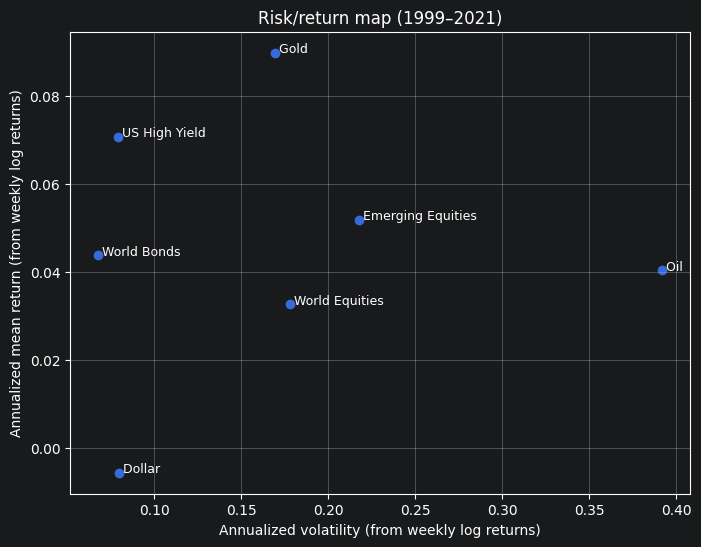

In [9]:
x = stats_table["vol_annual"]
y = stats_table["mean_annual"]

plt.figure(figsize=(8, 6))
plt.scatter(x, y)

for a in stats_table.index:
    plt.text(x[a], y[a], " " + a, fontsize=9)

plt.xlabel("Annualized volatility (from weekly log returns)")
plt.ylabel("Annualized mean return (from weekly log returns)")
plt.title("Risk/return map (1999–2021)")
plt.show()


## 6. Stylized fact #1 — volatility is time-varying (rolling volatility)

We compute 1-year rolling volatility (52 weeks).
✅ Teaching prompt: *What macro regimes show up clearly in this plot?*  


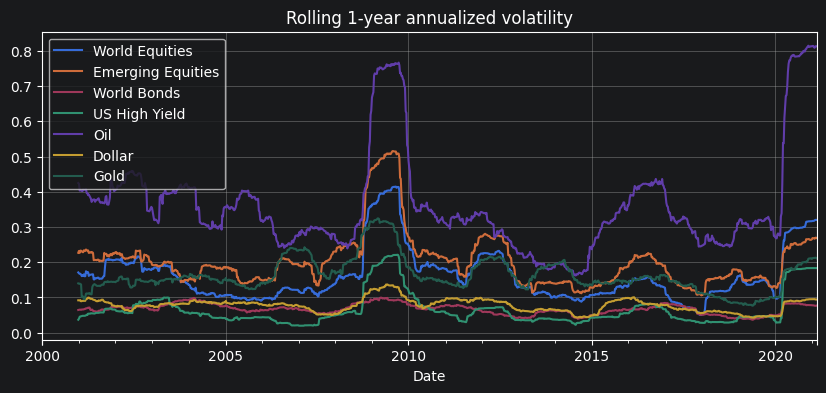

In [10]:
ROLL = 52  # 1 year in weekly data

rolling_vol = log_ret.rolling(ROLL).std() * np.sqrt(WEEKS_PER_YEAR)

rolling_vol.plot(title="Rolling 1-year annualized volatility")
plt.show()


### Co-movement of volatility across assets

In [11]:
# Correlation of rolling volatilities (simple snapshot)
vol_corr = rolling_vol.dropna().corr()
vol_corr


,World Equities,Emerging Equities,World Bonds,US High Yield,Oil,Dollar,Gold
World Equities,1.000000,0.910686,0.492633,0.926500,0.824209,0.678582,0.635260
Emerging Equities,0.910686,1.000000,0.544521,0.823879,0.703302,0.751558,0.753818
World Bonds,0.492633,0.544521,1.000000,0.584424,0.621811,0.733967,0.545898
US High Yield,0.926500,0.823879,0.584424,1.000000,0.910906,0.667422,0.594477
Oil,0.824209,0.703302,0.621811,0.910906,1.000000,0.659526,0.444430
Dollar,0.678582,0.751558,0.733967,0.667422,0.659526,1.000000,0.615225
Gold,0.635260,0.753818,0.545898,0.594477,0.444430,0.615225,1.000000


🧩 Student challenge: *Which pair has the highest volatility correlation? Any intuition?*

## 7. Stylized fact #2 — volatility clustering (ACF of |returns| and returns²)

A classic way to show clustering:
- Compute ACF of $|r_t|$ and $r_t^2$
- Persistence in these series indicates volatility clustering.

We do it for one asset (default: World Equities), then you can loop over assets.


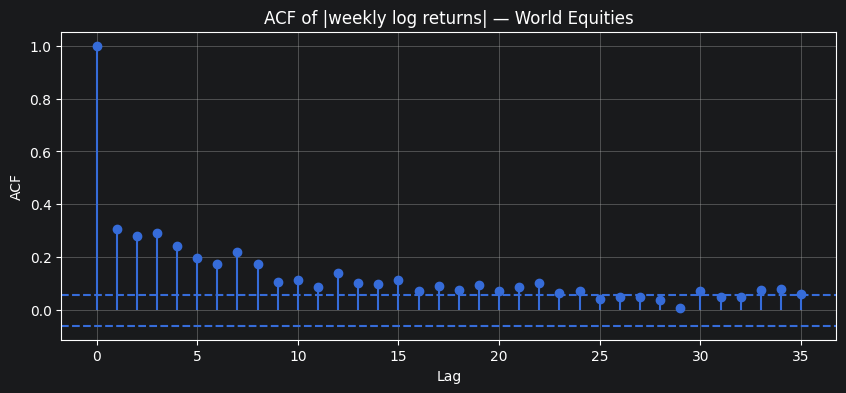

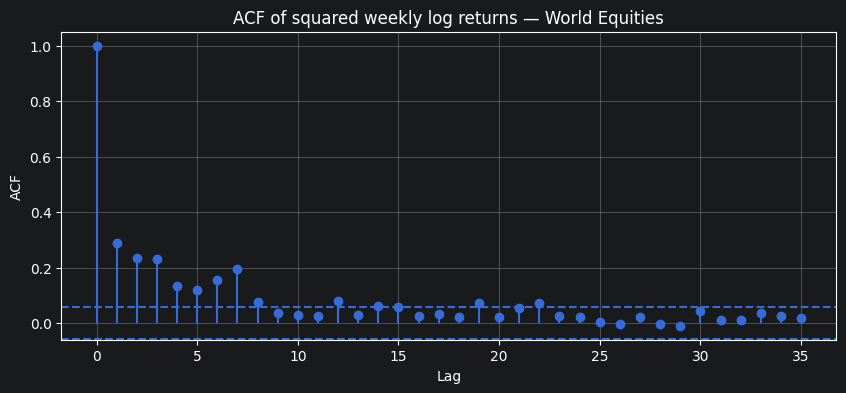

In [12]:
def plot_acf(series: pd.Series, nlags: int = 30, title: str = ""):
    s = series.dropna().values
    a = acf(s, nlags=nlags, fft=True)
    n = len(s)
    conf = 1.96 / np.sqrt(n)  # approx 95% band under white-noise null

    plt.figure(figsize=(10, 4))
    plt.stem(range(len(a)), a, basefmt=" ")
    plt.axhline(conf, linestyle="--")
    plt.axhline(-conf, linestyle="--")
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.title(title)
    plt.show()

asset = "World Equities"
r = log_ret[asset].dropna()

plot_acf(np.abs(r), nlags=35, title=f"ACF of |weekly log returns| — {asset}")
plot_acf(r**2, nlags=35, title=f"ACF of squared weekly log returns — {asset}")


🧩 Student challenge: *Repeat for Oil and compare the persistence. What changes?*

## 8. Stylized fact #3 — leverage effect (asymmetric volatility)

A simple empirical check:
- Compute correlation between today's return $r_t$ and **next period** volatility proxy $|r_{t+1}|$ or $r_{t+1}^2$.
- For equities, leverage effect suggests **negative correlation**.

We compute this for all assets and also show a small "negative vs positive" conditioning plot.


In [13]:
def leverage_proxy_corr(r: pd.Series) -> float:
    # corr(r_t, |r_{t+1}|)
    return r.corr(np.abs(r.shift(-1)))

lev = pd.Series({a: leverage_proxy_corr(log_ret[a].dropna()) for a in log_ret.columns})
lev.sort_values()


World Equities      -0.268958
Emerging Equities   -0.254462
US High Yield       -0.210212
Oil                 -0.068294
Dollar              -0.026425
Gold                 0.016773
World Bonds          0.034345
dtype: float64

World Equities
E[ |r_{t+1}| | r_t < 0 ] = 0.020588810705353927
E[ |r_{t+1}| | r_t >= 0 ] = 0.014054058612208426


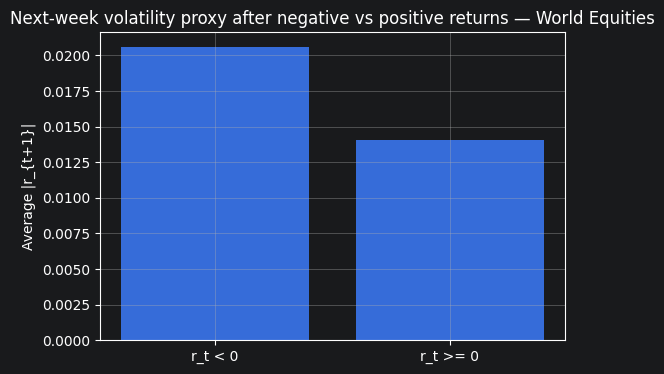

In [14]:
asset = "World Equities"
r = log_ret[asset].dropna()
future_abs = np.abs(r.shift(-1))

# Conditional means: next-period |r| after negative vs positive return
cond = pd.DataFrame({"r_t": r, "|r_t+1|": future_abs}).dropna()
mean_neg = cond.loc[cond["r_t"] < 0, "|r_t+1|"].mean()
mean_pos = cond.loc[cond["r_t"] >= 0, "|r_t+1|"].mean()

print(asset)
print("E[ |r_{t+1}| | r_t < 0 ] =", mean_neg)
print("E[ |r_{t+1}| | r_t >= 0 ] =", mean_pos)

plt.figure(figsize=(6,4))
plt.bar(["r_t < 0", "r_t >= 0"], [mean_neg, mean_pos])
plt.title(f"Next-week volatility proxy after negative vs positive returns — {asset}")
plt.ylabel("Average |r_{t+1}|")
plt.show()


✅ Teaching prompt: *Why might commodities display a different asymmetry than equities?*

## 9. A practical risk metric: drawdowns and max drawdown

Students often understand risk better when they see drawdowns.

We compute:
- Equity curve from log returns
- Drawdown series
- Maximum drawdown


Max drawdown: -0.583654173307308


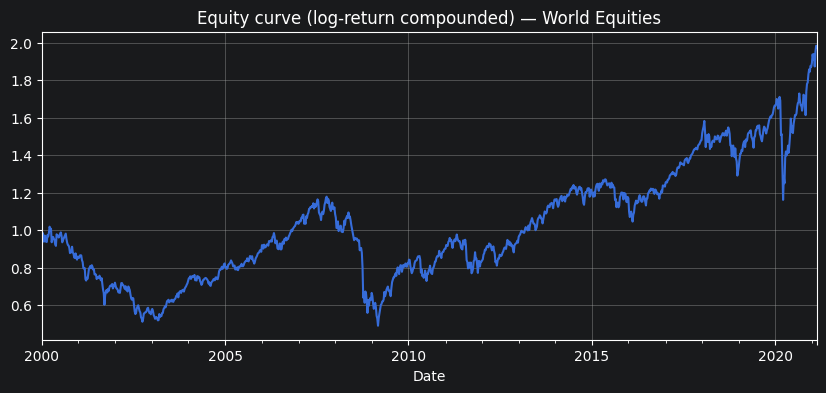

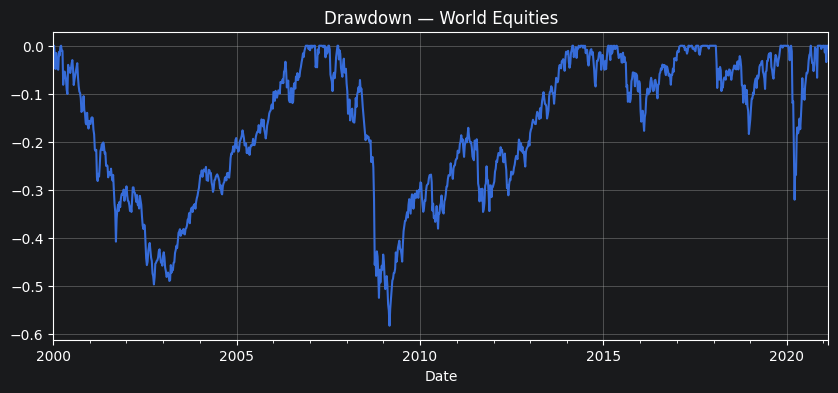

In [15]:
def equity_curve_from_log_returns(r: pd.Series, start=1.0) -> pd.Series:
    return start * np.exp(r.cumsum())

def drawdown(equity: pd.Series) -> pd.Series:
    peak = equity.cummax()
    return equity / peak - 1.0

asset = "World Equities"
eq = equity_curve_from_log_returns(log_ret[asset].dropna())
dd = drawdown(eq)

print("Max drawdown:", dd.min())

eq.plot(title=f"Equity curve (log-return compounded) — {asset}")
plt.show()

dd.plot(title=f"Drawdown — {asset}")
plt.show()


🧩 Student challenge: *Compute max drawdown for Gold and compare with Equities.*

## 10. Mini-portfolio lab: equal-weight vs inverse-vol weights

We build two simple portfolios (rebalanced weekly):
1. Equal-weight (EW)
2. Inverse-vol (IV) using a rolling 52-week volatility estimate

This is a clean way to connect descriptive statistics to an allocation rule.


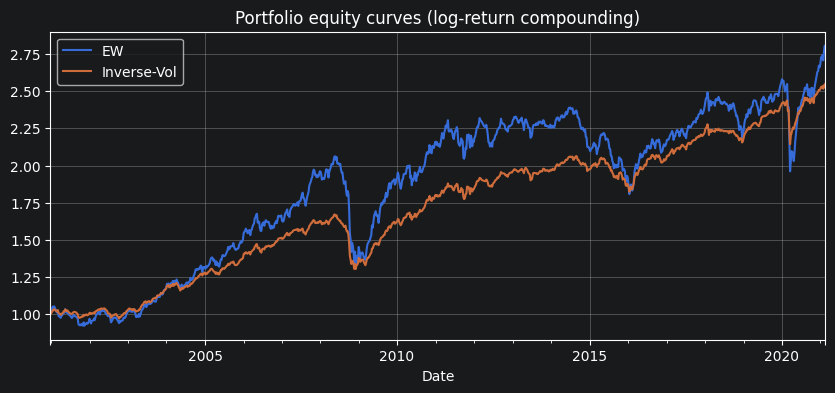

,EW,Inverse-Vol
ann_return,0.052006,0.046982
ann_vol,0.101331,0.052521
sharpe_(rf=0),0.500334,0.874165


In [16]:
def portfolio_returns(returns: pd.DataFrame, weights: pd.DataFrame) -> pd.Series:
    # Align and compute portfolio simple return approximation using log-returns: r_p = sum w_i r_i
    # (This is exact only for simple returns, but for small weekly moves it is a good approximation.)
    aligned = returns.join(weights, how="inner", lsuffix="_r", rsuffix="_w")
    r = aligned[[c for c in aligned.columns if c.endswith("_r")]]
    w = aligned[[c for c in aligned.columns if c.endswith("_w")]]
    r.columns = returns.columns
    w.columns = weights.columns
    return (r * w).sum(axis=1)

r = log_ret.dropna()

# 1) Equal weight
w_ew = pd.DataFrame(1.0 / r.shape[1], index=r.index, columns=r.columns)

# 2) Inverse-vol weights (rolling 1y vol, then normalize)
roll_vol = r.rolling(52).std()
inv_vol = 1.0 / roll_vol
w_iv = inv_vol.div(inv_vol.sum(axis=1), axis=0).dropna()

rp_ew = portfolio_returns(r, w_ew.loc[w_iv.index])
rp_iv = portfolio_returns(r, w_iv)

eq_ew = equity_curve_from_log_returns(rp_ew)
eq_iv = equity_curve_from_log_returns(rp_iv)

pd.DataFrame({"EW": eq_ew, "Inverse-Vol": eq_iv}).plot(title="Portfolio equity curves (log-return compounding)")
plt.show()

# Compare annualized stats
def ann_stats_from_log(rp: pd.Series) -> pd.Series:
    m = rp.mean()
    s = rp.std()
    return pd.Series({
        "ann_return": annualize_from_weekly_log(m),
        "ann_vol": annualize_vol_from_weekly(s),
        "sharpe_(rf=0)": (m / s) * np.sqrt(WEEKS_PER_YEAR),
    })

pd.DataFrame({"EW": ann_stats_from_log(rp_ew), "Inverse-Vol": ann_stats_from_log(rp_iv)})


✅ Teaching prompt: *Why can an inverse-vol rule reduce drawdowns? What are its weaknesses?*

## 11. Estimation uncertainty: bootstrap CI for the mean return

Key message for students:
- Sample mean is noisy.
- Confidence intervals can be wide, even with 20+ years of weekly data.

We bootstrap the annualized mean return for one asset.


World Equities
Point estimate (annual mean): 0.032608769246514235
95% bootstrap CI: (np.float64(-0.043233588060996864), np.float64(0.11392259408766675))


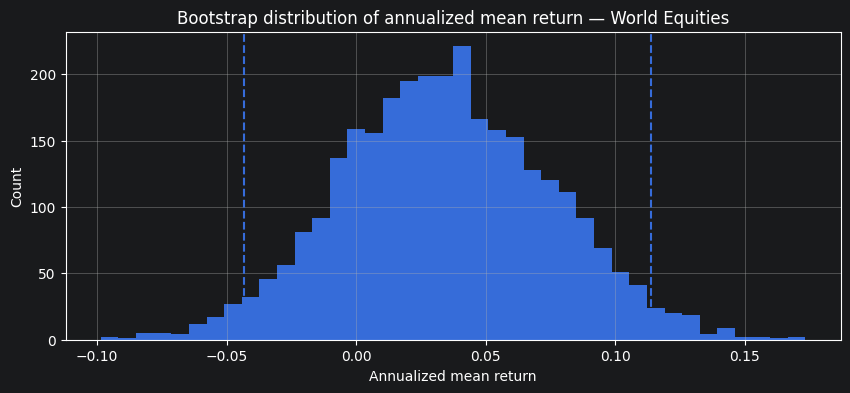

In [17]:
def bootstrap_annual_mean_log(r: pd.Series, n_boot: int = 5000) -> np.ndarray:
    x = r.dropna().values
    n = len(x)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        sample = np.random.choice(x, size=n, replace=True)
        boots[b] = annualize_from_weekly_log(sample.mean())
    return boots

asset = "World Equities"
boots = bootstrap_annual_mean_log(log_ret[asset], n_boot=3000)

ci_low, ci_high = np.percentile(boots, [2.5, 97.5])
point = annualize_from_weekly_log(log_ret[asset].dropna().mean())

print(asset)
print("Point estimate (annual mean):", point)
print("95% bootstrap CI:", (ci_low, ci_high))

plt.figure(figsize=(10,4))
plt.hist(boots, bins=40)
plt.axvline(ci_low, linestyle="--")
plt.axvline(ci_high, linestyle="--")
plt.title(f"Bootstrap distribution of annualized mean return — {asset}")
plt.xlabel("Annualized mean return")
plt.ylabel("Count")
plt.show()


✅ Teaching prompt: *How would this uncertainty affect Markowitz/CAPM outputs?*

## 12. Wrap-up checklist

**What we did**
- Loaded weekly asset levels and computed simple & log returns.
- Computed annualized mean/vol and higher moments.
- Visualized 3 major volatility stylized facts:
  1) time-varying volatility (rolling vol)
  2) clustering (ACF of |r| and r²)
  3) leverage effect (asymmetric response of volatility)
- Built two simple portfolios (EW vs inverse-vol) to connect statistics to allocation.

**Suggested extensions (next classes)**
- Normality tests and QQ-plots
- Linear model estimation (OLS) and inference
- AR/GARCH models for volatility
